# asses the history of runs


In [3]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [4]:



df=pd.read_csv("/fred/oz061/kandrych/smac/20260501_no_puffed_rim_budget1/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260501_no_puffed_rim_budget1/smac_results/after_optimisation/"
Path(results_dir).mkdir(parents=True, exist_ok=True)
df


,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.029033,1220.0,0.364058,135.736412,0.00010,1.178507,200.0,4.782004,0.298674,0.556127,0.7,-0.831973,349,1256366033,1.1,2.070449e+01,119.283132,1
1,0.029645,1220.0,0.715218,135.419358,0.00010,1.258447,200.0,4.339941,0.265808,0.554565,0.8,-0.826109,464,1256366033,1.1,2.079945e+01,156.181738,1
2,0.042443,1220.0,0.266392,137.675575,0.00010,1.170313,200.0,4.537051,0.282681,0.559848,0.7,-0.835522,327,1256366033,1.1,2.080703e+01,134.440245,1
3,0.042443,1220.0,0.192226,136.204286,0.00010,1.176347,200.0,4.483552,0.128449,0.555506,0.7,-0.835522,355,1256366033,1.1,2.082386e+01,118.900667,1
4,0.013592,1220.0,0.636349,135.771422,0.00010,1.197443,200.0,4.795175,0.266614,0.555385,0.8,-0.833278,451,1256366033,1.1,2.085310e+01,131.716707,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.000623,1220.0,1.752041,232.315322,0.00001,1.613324,50.0,0.838251,0.904709,0.133444,0.5,1.170106,89,1256366033,1.1,1.390559e+06,150.403587,1
496,0.031595,1220.0,0.551854,274.625447,0.00001,1.427567,10.0,1.551170,0.421275,0.056961,0.7,1.364286,106,1256366033,1.1,1.423922e+06,124.255827,1
497,0.046334,1220.0,0.814204,190.623897,0.00001,1.698578,10.0,2.504520,0.623896,0.187491,0.3,1.752165,24,1256366033,1.1,1.443865e+06,108.980115,1
498,0.000022,1220.0,1.687976,165.049378,0.00001,1.880646,200.0,3.313524,0.826579,0.213633,0.8,1.832742,27,1256366033,1.1,1.447275e+06,122.421515,1


### Best configs table (at max budget)

In [3]:
top = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
print("Top 5 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 5 max budget trials:


,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.029033,1220.0,0.364058,135.736412,0.0001,1.178507,200.0,4.782004,0.298674,0.556127,0.7,-0.831973,349,1256366033,1.1,20.704493,119.283132,1
1,0.029645,1220.0,0.715218,135.419358,0.0001,1.258447,200.0,4.339941,0.265808,0.554565,0.8,-0.826109,464,1256366033,1.1,20.799452,156.181738,1
2,0.042443,1220.0,0.266392,137.675575,0.0001,1.170313,200.0,4.537051,0.282681,0.559848,0.7,-0.835522,327,1256366033,1.1,20.807033,134.440245,1
3,0.042443,1220.0,0.192226,136.204286,0.0001,1.176347,200.0,4.483552,0.128449,0.555506,0.7,-0.835522,355,1256366033,1.1,20.823861,118.900667,1
4,0.013592,1220.0,0.636349,135.771422,0.0001,1.197443,200.0,4.795175,0.266614,0.555385,0.8,-0.833278,451,1256366033,1.1,20.853103,131.716707,1


### Pairwise sanity checks (parameter vs cost)


['zone_1_-gamma_exp', 'zone_1_Rc', 'zone_1_dust_mass', 'zone_1_flaring_exp', 'zone_1_scale_height', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction', 'zone_1_surface_density_exp']


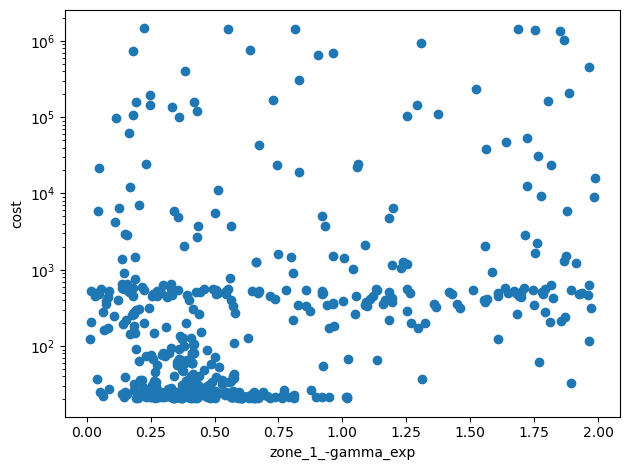

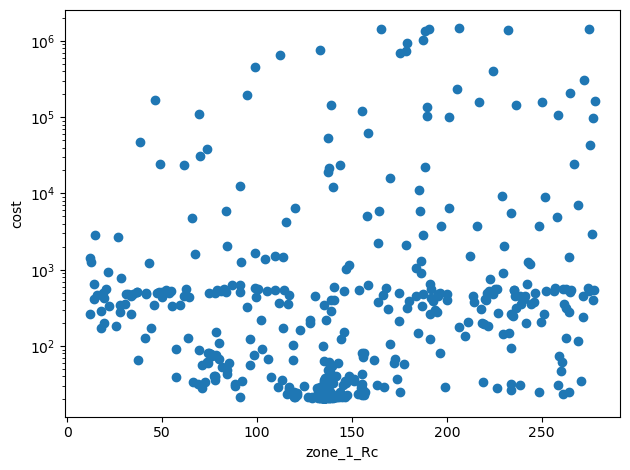

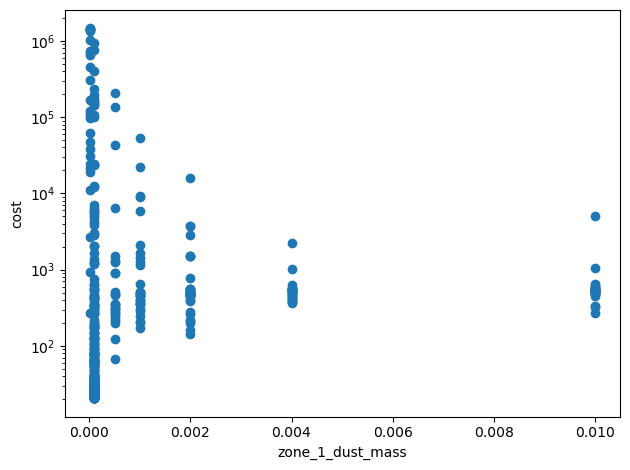

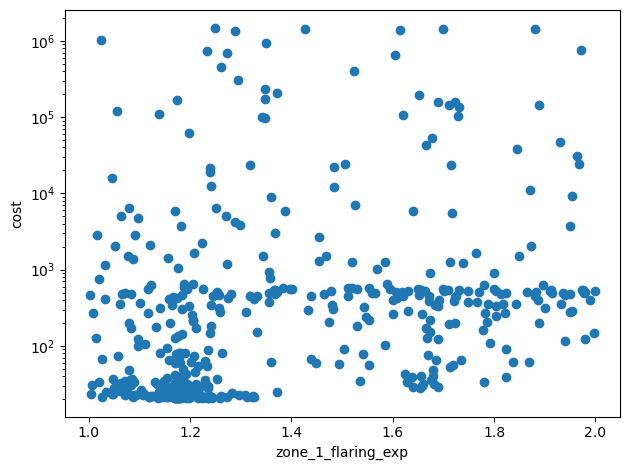

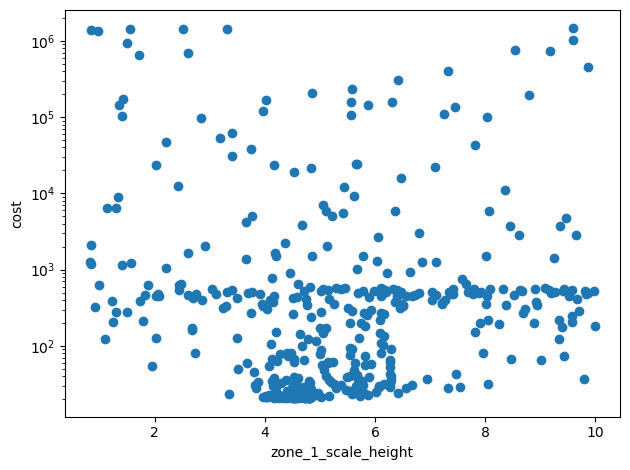

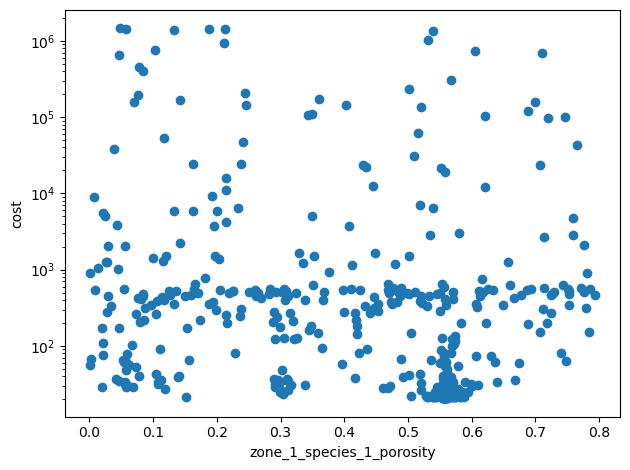

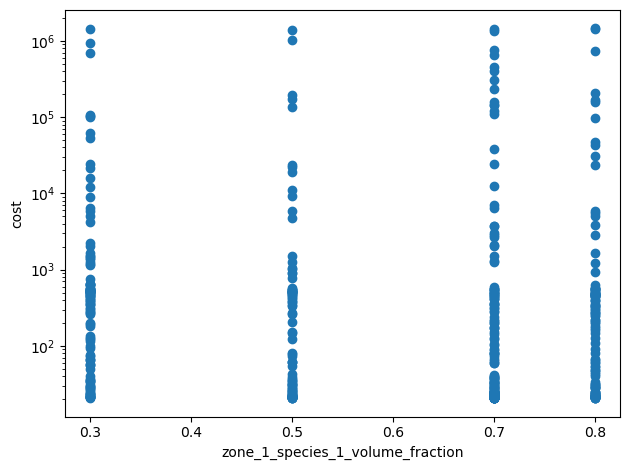

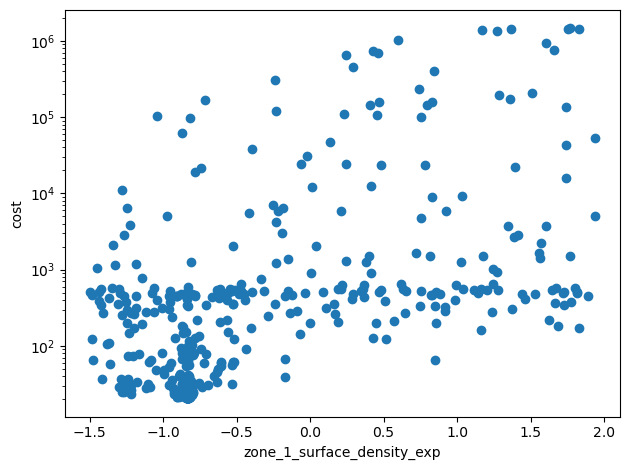

In [4]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "alpha_viscosity", 'zone_1_gas_to_dust', 'zone_1_species_1_amin'}

param_cols = [c for c in df.columns if c not in exclude]
print(param_cols)

for p in param_cols:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        plt.scatter(df[p], df["cost"])
        plt.xlabel(p); plt.ylabel("cost")
        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.savefig(results_dir +f"scatter_{p}.png", dpi=150)
        plt.show()
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [5]:
df.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
1.1,500.0,35031.263933,180445.925298,20.704493,24.258991,122.642985,531.624793,1.452161e+06


### Parameter importance (fast, practical)

In [6]:
def binned_medians(df, param, bins=2):
    s = df[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in df.columns:
        bm = binned_medians(df[df["budget"] == df["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(11.973, 136.789]      40.318102
(136.789, 277.901]    300.903296
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(1.0010000000000001, 1.235]     26.887554
(1.235, 1.999]                 458.689589
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(-0.00099, 0.0001]     32.397661
(0.0001, 0.01]        501.573302
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
bin
(0.538, 0.793]                       24.868517
(-0.00015000000000000007, 0.538]    417.937173
Name: cost, dtype: float64


### Clustering of “good” solutions (degeneracies)

In [7]:
good = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
count,5.000000,5.0,5.000000,5.000000,5.0000,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000e+00,5.0,5.000000,5.000000,5.0
mean,0.031431,1220.0,0.434849,136.161411,0.0001,1.196211,200.0,4.587544,0.248445,0.556286,0.740000,-0.832481,389.200000,1.256366e+09,1.1,20.797588,132.104498,1.0
std,0.011934,0.0,0.229926,0.891332,0.0000,0.036240,0.0,0.197229,0.068421,0.002067,0.054772,0.003873,63.381385,0.000000e+00,0.0,0.055972,15.199080,0.0
min,0.013592,1220.0,0.192226,135.419358,0.0001,1.170313,200.0,4.339941,0.128449,0.554565,0.700000,-0.835522,327.000000,1.256366e+09,1.1,20.704493,118.900667,1.0
25%,0.029033,1220.0,0.266392,135.736412,0.0001,1.176347,200.0,4.483552,0.265808,0.555385,0.700000,-0.835522,349.000000,1.256366e+09,1.1,20.799452,119.283132,1.0
50%,0.029645,1220.0,0.364058,135.771422,0.0001,1.178507,200.0,4.537051,0.266614,0.555506,0.700000,-0.833278,355.000000,1.256366e+09,1.1,20.807033,131.716707,1.0
75%,0.042443,1220.0,0.636349,136.204286,0.0001,1.197443,200.0,4.782004,0.282681,0.556127,0.800000,-0.831973,451.000000,1.256366e+09,1.1,20.823861,134.440245,1.0
max,0.042443,1220.0,0.715218,137.675575,0.0001,1.258447,200.0,4.795175,0.298674,0.559848,0.800000,-0.826109,464.000000,1.256366e+09,1.1,20.853103,156.181738,1.0


### Plot

In [8]:
curve = df.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,1.1,61299.386067
1,2,1.1,5948.272393
2,3,1.1,454150.456254
3,4,1.1,201.234510
4,5,1.1,579.007763
...,...,...,...
495,496,1.1,11129.125662
496,497,1.1,24.177717
497,498,1.1,22.236051
498,499,1.1,21.195164


## For the cornerplot


SMAC does not give a true posterior.
Your corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.

This is perfectly acceptable if you phrase it as:

“distribution of high-performing models”

In [9]:
# Restrict to highest fidelity
df_max = df[df["budget"] == df["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [10]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "alpha_viscosity", 'zone_1_gas_to_dust', 'zone_1_species_1_amin'}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['zone_1_-gamma_exp',
 'zone_1_Rc',
 'zone_1_dust_mass',
 'zone_1_flaring_exp',
 'zone_1_scale_height',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

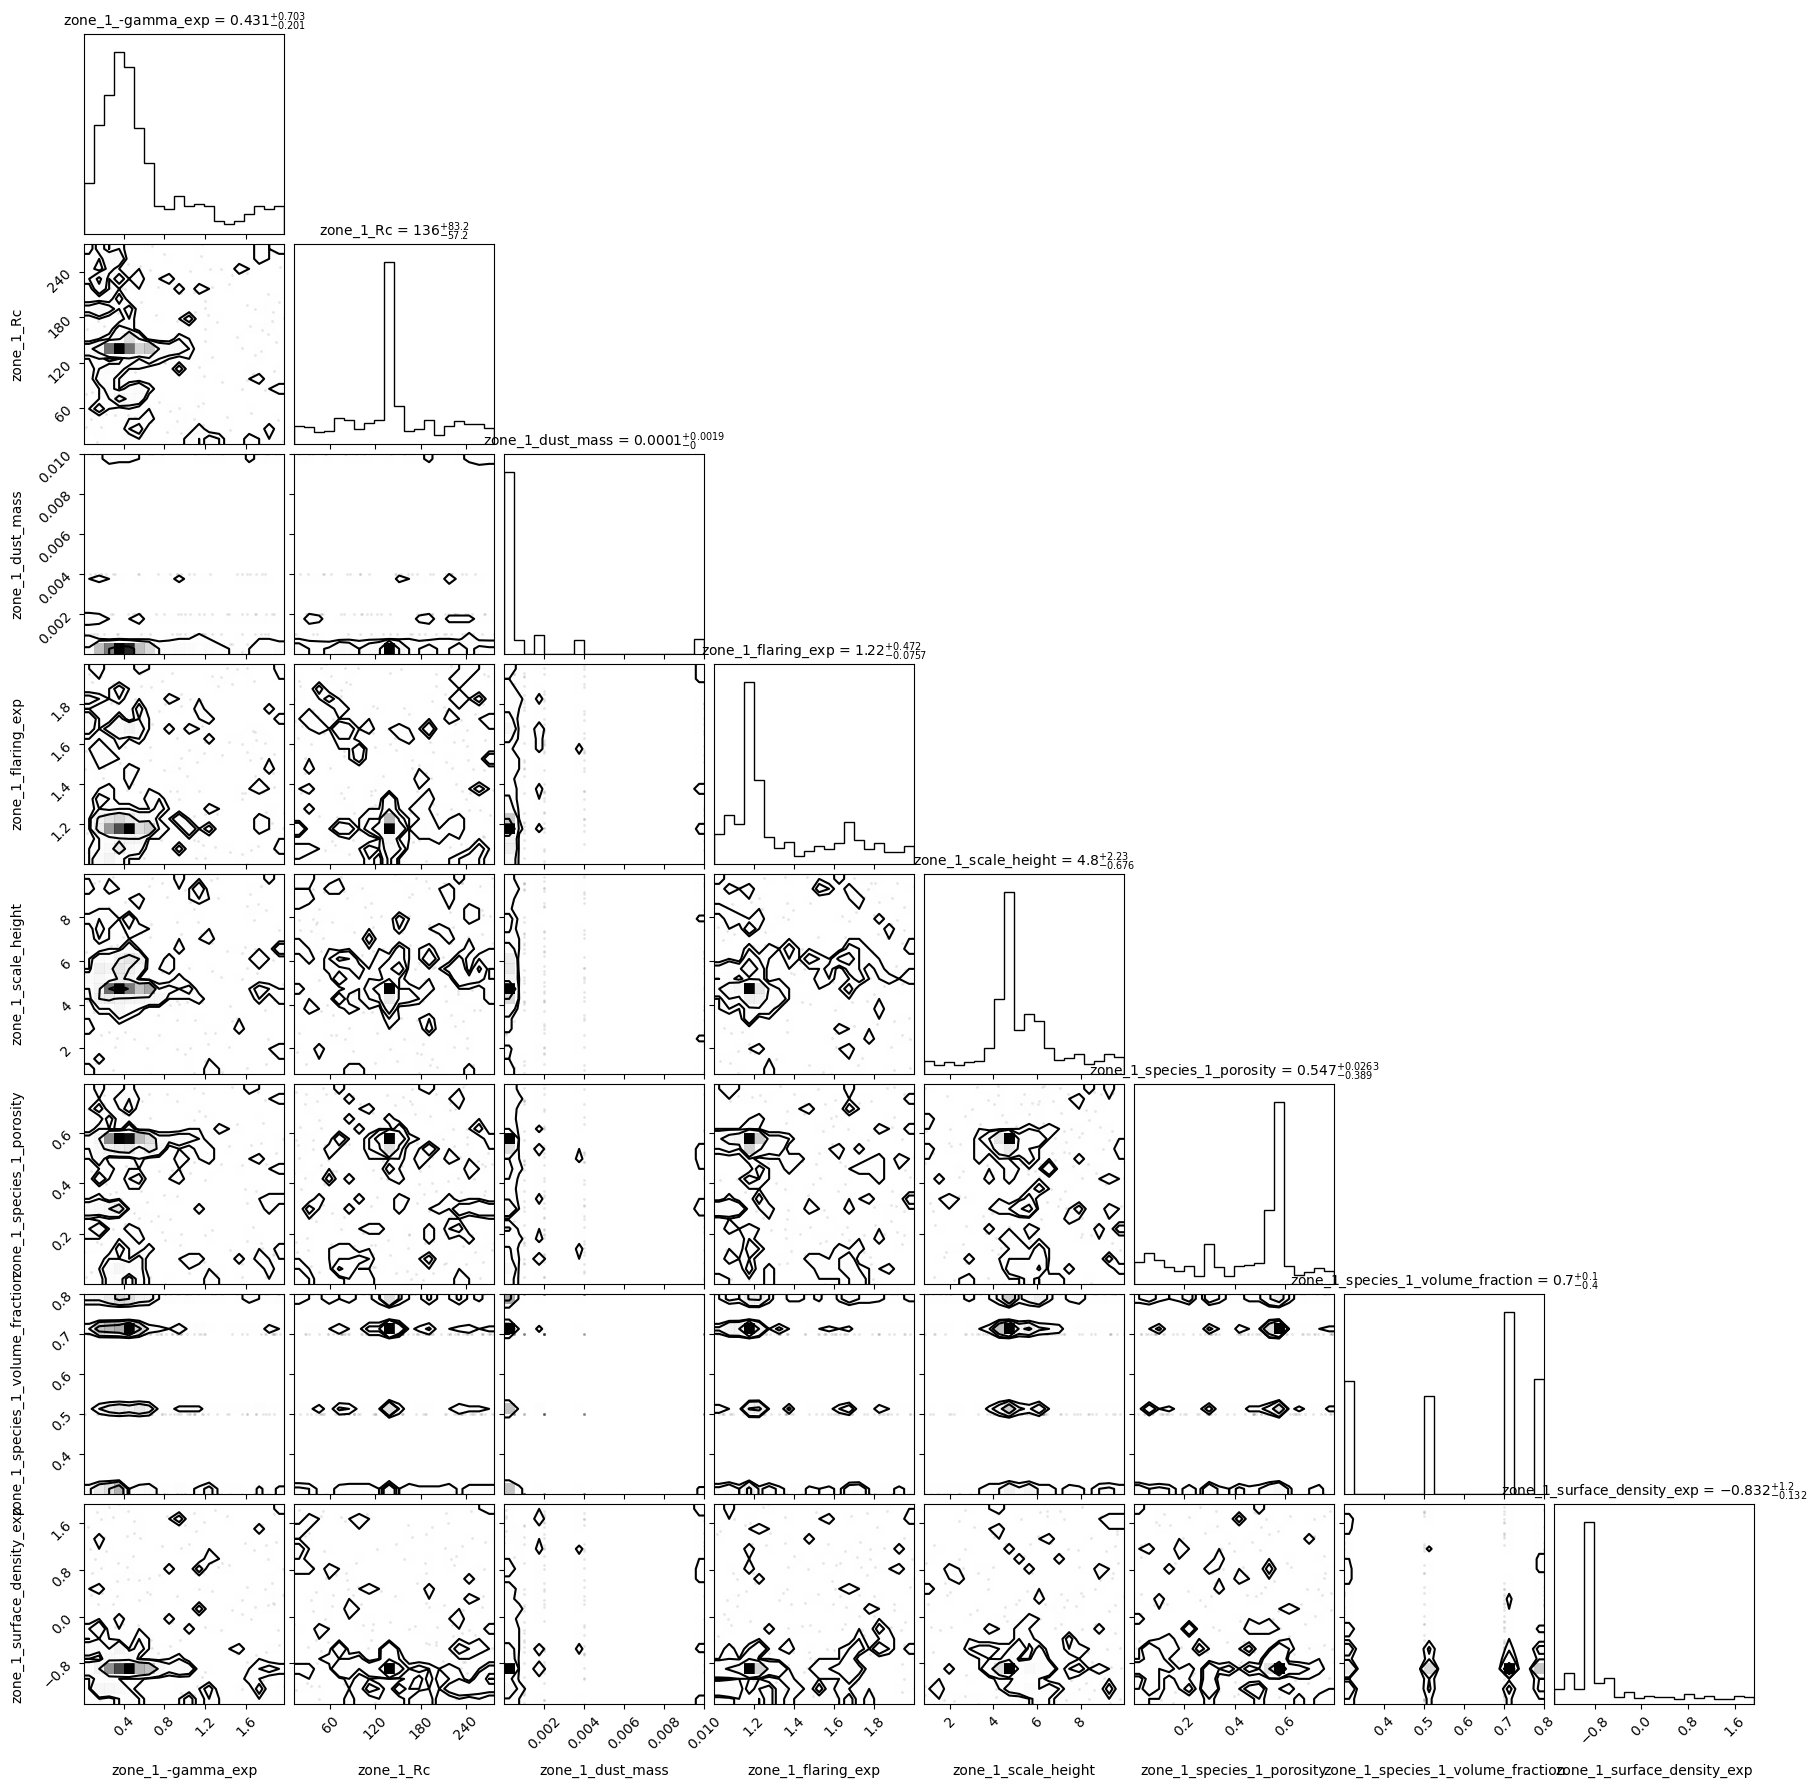

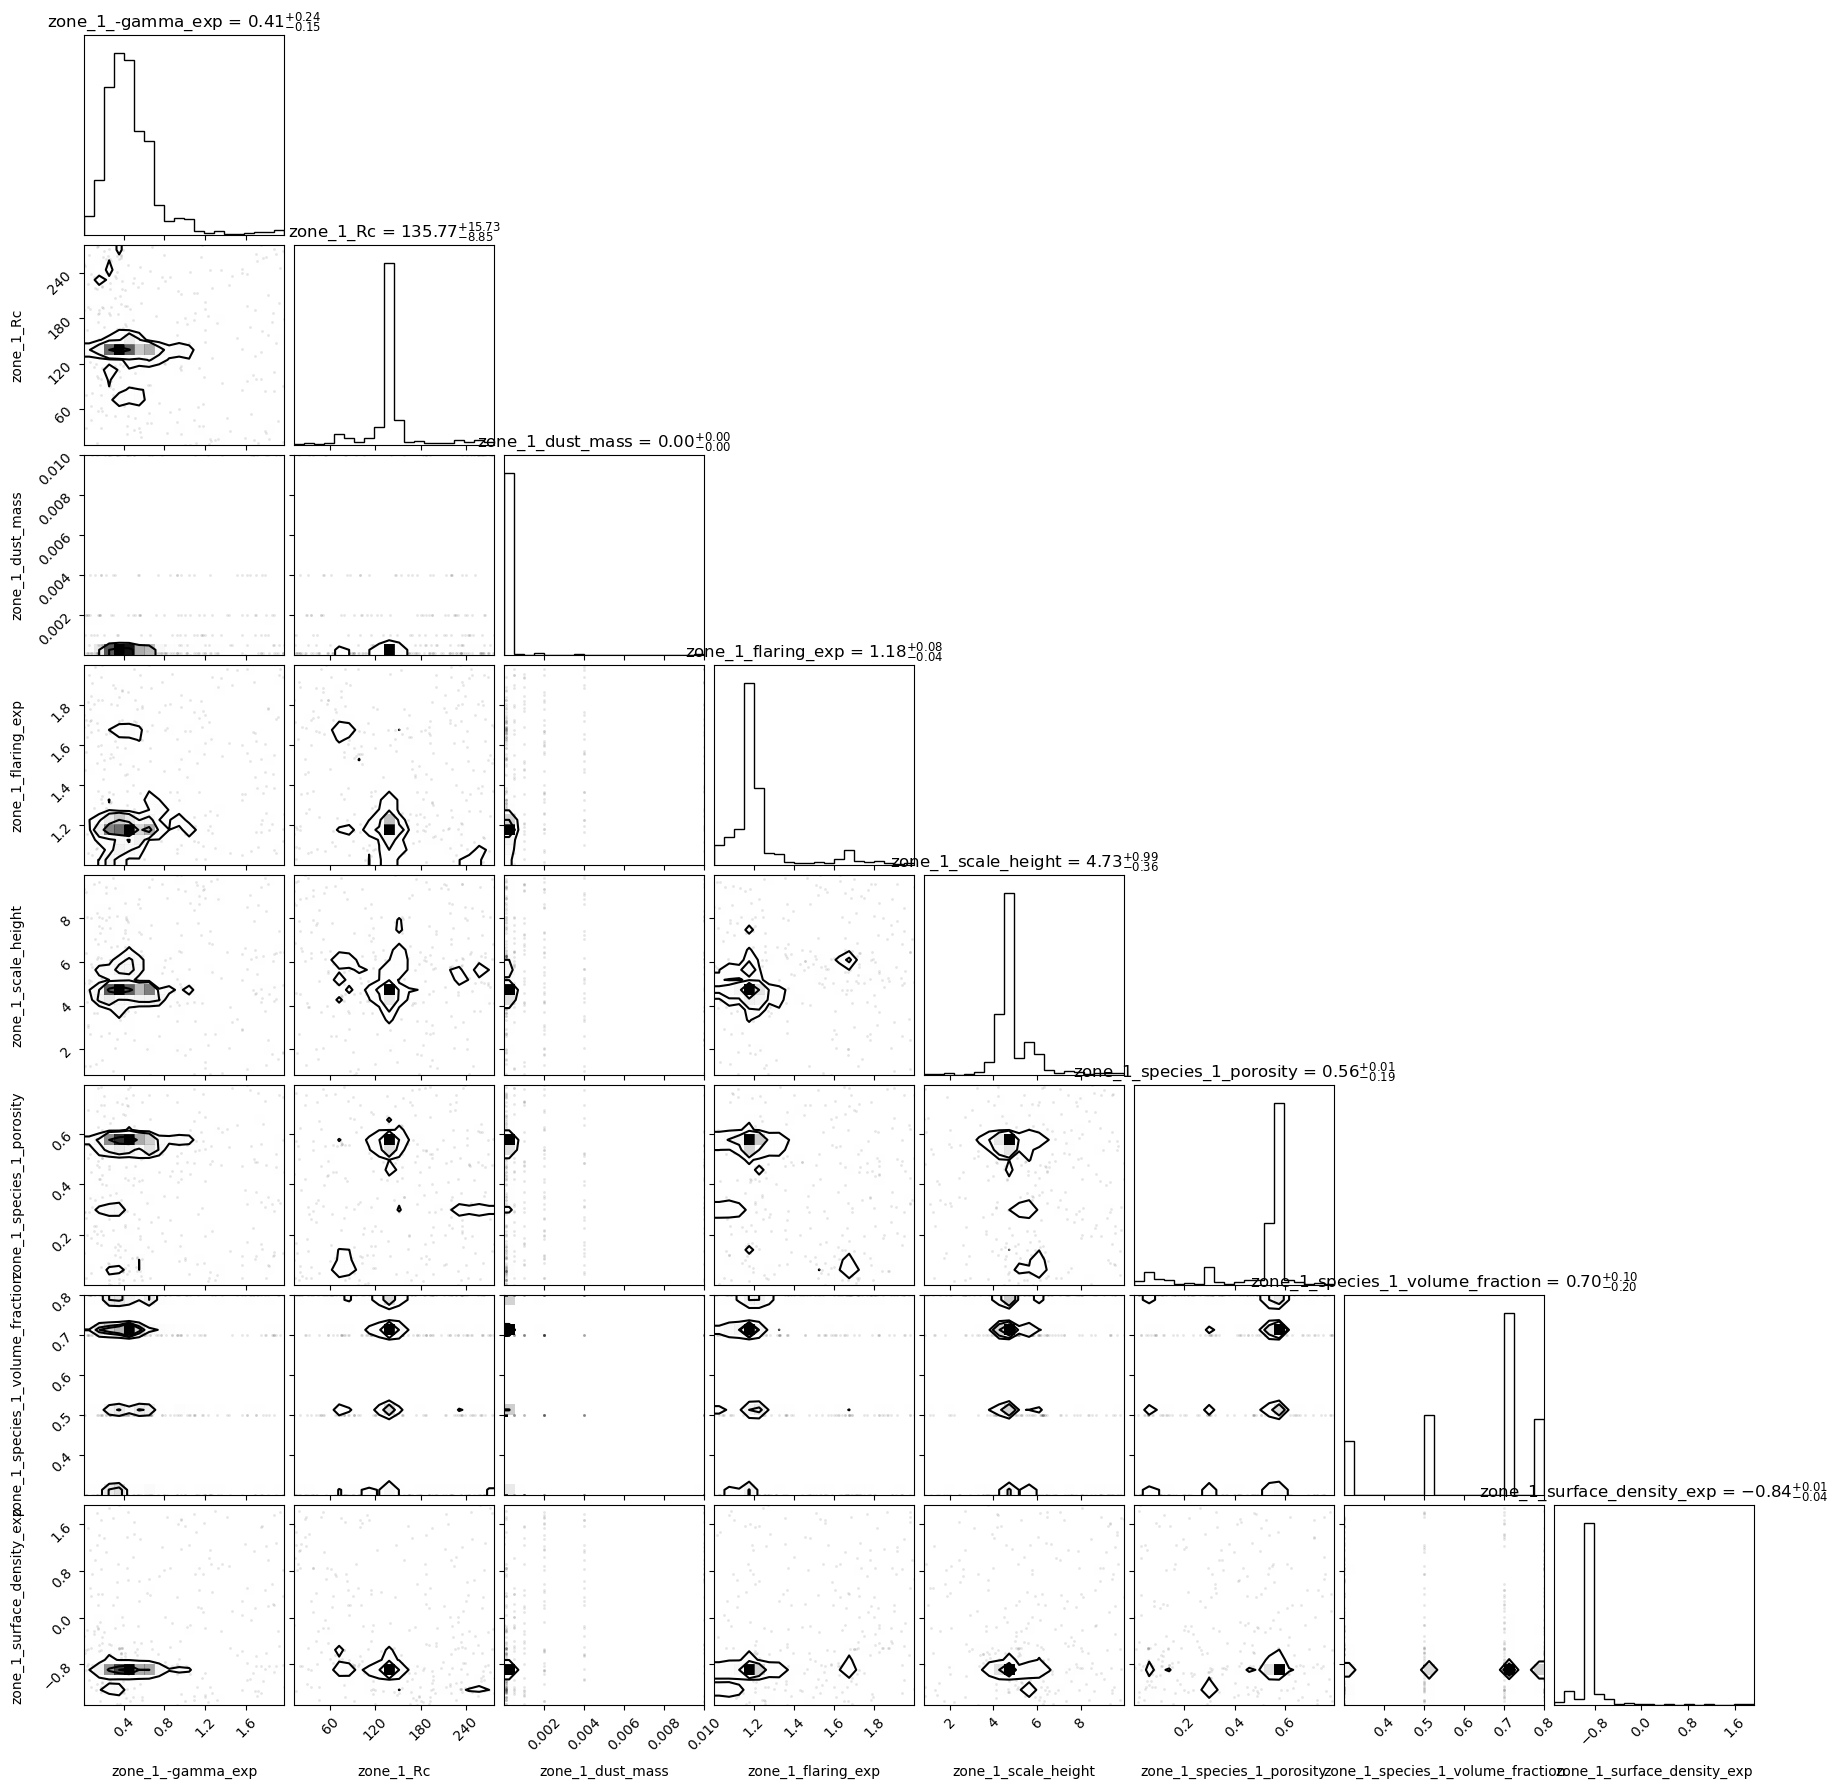

In [11]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

fig.savefig(results_dir +"corner_all_params.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)
fig.savefig(results_dir +"corner_all_params_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



In [12]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]

    data = d[params].values

    fig = corner.corner(
        data,
        labels=params,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
    )

    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)




In [13]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df,
    params=param_cols,
    budget=df["budget"].max(),
    outfile=results_dir+ "corner_best.png"
)


        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  450.000000          450.000000        450.000000   
mean    35.727777            1.280629          0.002062   
std      9.467874            0.141251          0.001145   
min      7.344311            1.002126          0.001000   
25%     32.581723            1.183190          0.001000   
50%     39.396461            1.229243          0.002000   
75%     40.677239            1.415979          0.002000   
max     49.999303            1.596036          0.004000   

       zone_1_species_1_porosity  
count                 450.000000  
mean                    0.323198  
std                     0.173498  
min                     0.005305  
25%                     0.256321  
50%                     0.262164  
75%                     0.352617  
max                     0.794124  


### Test code fro chatgpt, needs to be tested

In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import corner


def runhistory_to_df(smac, cs) -> pd.DataFrame:
    """Convert SMAC runhistory to a flat dataframe with params + metadata."""
    rh = smac.runhistory
    rows = []

    # SMAC RunHistory usually behaves like a dict: key->value
    for key, val in rh.items():
        # key typically has: config_id, seed, budget, instance
        cfg = rh.get_config(key.config_id)
        d = cfg.get_dictionary()

        row = dict(d)
        row["config_id"] = getattr(key, "config_id", None)
        row["seed"] = getattr(key, "seed", None)
        row["budget"] = getattr(key, "budget", None)
        row["instance"] = getattr(key, "instance", None)

        row["cost"] = getattr(val, "cost", None)
        row["time"] = getattr(val, "time", None)
        row["cpu_time"] = getattr(val, "cpu_time", None)
        row["status"] = getattr(val, "status", None)

        # Some SMAC versions store start/end times in val.additional_info
        add = getattr(val, "additional_info", None)
        if isinstance(add, dict):
            row["starttime"] = add.get("starttime", None)
            row["endtime"] = add.get("endtime", None)

        rows.append(row)

    df = pd.DataFrame(rows)

    # Helpful sorting if endtime exists
    if "endtime" in df.columns and df["endtime"].notna().any():
        df = df.sort_values(["endtime", "budget", "cost"], ascending=[True, True, True])
    else:
        df = df.sort_values(["budget", "cost"], ascending=[True, True])

    df = df.reset_index(drop=True)
    return df


def choose_param_columns(df: pd.DataFrame) -> list[str]:
    """Pick all columns that look like model params (exclude SMAC bookkeeping)."""
    exclude = {
        "config_id", "seed", "budget", "instance",
        "cost", "time", "cpu_time", "status",
        "starttime", "endtime",
    }
    return [c for c in df.columns if c not in exclude]


def split_into_groups(params: list[str], max_per_group: int = 10) -> list[list[str]]:
    """Split parameter list into chunks to keep corner readable."""
    if len(params) <= max_per_group:
        return [params]
    groups = []
    for i in range(0, len(params), max_per_group):
        groups.append(params[i:i + max_per_group])
    return groups


def safe_corner(
    df: pd.DataFrame,
    params: list[str],
    outpath: Path,
    *,
    weights: np.ndarray | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
):
    """Make one corner plot robustly, dropping NaNs and constant columns."""
    d = df.copy()

    # Keep only numeric params for corner
    numeric_params = []
    for p in params:
        if p not in d.columns:
            continue
        # coerce to numeric where possible; categorical corner plots are messy
        d[p] = pd.to_numeric(d[p], errors="coerce")
        if d[p].notna().any():
            numeric_params.append(p)

    if len(numeric_params) == 0:
        print(f"[corner] Skip {outpath.name}: no numeric params found.")
        return

    d = d.dropna(subset=numeric_params + ["cost"], how="any")
    if len(d) < 5:
        print(f"[corner] Skip {outpath.name}: too few points ({len(d)}).")
        return

    # Remove constant columns (corner can choke / be useless)
    keep = []
    for p in numeric_params:
        if d[p].nunique(dropna=True) > 1:
            keep.append(p)

    if len(keep) < 2:
        print(f"[corner] Skip {outpath.name}: <2 varying params.")
        return

    data = d[keep].to_numpy(dtype=float)

    # Align truths length if provided
    t = None
    if truths is not None:
        if len(truths) == len(params):
            # Map truths to the kept params
            truth_map = {p: v for p, v in zip(params, truths)}
            t = [truth_map[p] for p in keep]
        elif len(truths) == len(keep):
            t = truths
        else:
            print(f"[corner] Warning: truths length mismatch for {outpath.name}; ignoring truths.")
            t = None

    fig = corner.corner(
        data,
        labels=keep,
        weights=weights,
        truths=t,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
        title_kwargs={"fontsize": 10},
    )
    if title:
        fig.suptitle(title, fontsize=12)

    fig.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[corner] Wrote {outpath}")


def main_corner_analysis(smac, cs, results_dir: Path):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    df = runhistory_to_df(smac, cs)
    df.to_csv(results_dir / "trials.csv", index=False)
    print(f"[analysis] Saved trials table: {results_dir/'trials.csv'}  (N={len(df)})")

    params_all = choose_param_columns(df)
    print(f"[analysis] Detected {len(params_all)} parameter columns.")

    # Prefer max budget for “physical interpretation”
    max_budget = df["budget"].max()
    df_max = df[df["budget"] == max_budget].copy()
    df_max = df_max.dropna(subset=["cost"])
    print(f"[analysis] Max budget = {max_budget} ; N(max-budget)={len(df_max)}")

    # Prepare directories
    corner_dir = results_dir / "corner"
    corner_dir.mkdir(exist_ok=True)

    # If too many params, split into groups
    groups = split_into_groups(params_all, max_per_group=10)

    # ---- 1) Max budget: all points ----
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_max,
            grp,
            corner_dir / f"corner_maxbudget_all_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - all trials - group {gi}",
        )

    # ---- 2) Max budget: best quantile (e.g. best 30%) ----
    best_q = 0.30
    if len(df_max) > 0:
        cut = df_max["cost"].quantile(best_q)
        df_bestq = df_max[df_max["cost"] <= cut].copy()
        print(f"[analysis] Best {int(best_q*100)}% cutoff: cost <= {cut:.6g} ; N={len(df_bestq)}")

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_bestq,
                grp,
                corner_dir / f"corner_maxbudget_best{int(best_q*100)}pct_group{gi:02d}.png",
                title=f"Max budget ({max_budget}) - best {int(best_q*100)}% - group {gi}",
            )

    # ---- 3) Max budget: top N ----
    topN = 50
    df_top = df_max.nsmallest(topN, "cost").copy()
    print(f"[analysis] Top {topN} at max budget: N={len(df_top)}")
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_top,
            grp,
            corner_dir / f"corner_maxbudget_top{topN}_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - top {topN} - group {gi}",
        )

    # ---- 4) Weighted by 1/cost (emphasize good models) ----
    # Use best-quantile selection + weights for stability
    if len(df_max) > 0:
        df_w = df_bestq if "df_bestq" in locals() and len(df_bestq) >= 5 else df_max.copy()
        # Avoid divide-by-zero
        w = 1.0 / np.maximum(df_w["cost"].to_numpy(dtype=float), 1e-12)

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_w,
                grp,
                corner_dir / f"corner_maxbudget_weighted_group{gi:02d}.png",
                weights=w,
                title=f"Max budget ({max_budget}) - weighted by 1/cost - group {gi}",
            )

    # ---- 5) Per-budget diagnostic corner plots (small groups only) ----
    # These can be a lot; keep only first group by default (edit if you want all groups)
    budgets = sorted(df["budget"].dropna().unique())
    diag_dir = corner_dir / "by_budget"
    diag_dir.mkdir(exist_ok=True)

    # Only do first group by default to avoid 100s of plots
    grp = groups[0] if groups else params_all

    for b in budgets:
        df_b = df[df["budget"] == b].dropna(subset=["cost"]).copy()
        if len(df_b) < 10:
            continue
        safe_corner(
            df_b,
            grp,
            diag_dir / f"corner_budget_{b:g}.png",
            title=f"Budget {b:g} - diagnostics (group 1)",
        )

    # ---- Extra: save “trajectory” (best-so-far) table ----
    # Compute best-so-far ordering by time if available, otherwise row order
    if "endtime" in df.columns and df["endtime"].notna().any():
        df_ord = df.sort_values("endtime").copy()
    else:
        df_ord = df.copy()

    best_cost = np.inf
    keep_idx = []
    for i, row in df_ord.iterrows():
        if row["cost"] < best_cost:
            best_cost = row["cost"]
            keep_idx.append(i)

    traj_df = df_ord.loc[keep_idx].reset_index(drop=True)
    traj_df.to_csv(results_dir / "trajectory_best_so_far.csv", index=False)
    print(f"[analysis] Saved trajectory: {results_dir/'trajectory_best_so_far.csv'}  (K={len(traj_df)})")

    # Save some quick summaries
    (df.groupby("budget")["cost"].describe()
       .to_csv(results_dir / "cost_by_budget.csv"))
    print(f"[analysis] Saved cost summary: {results_dir/'cost_by_budget.csv'}")


# ---- call it ----
# Use results_dir you already created; I suggest putting plots under results_dir
main_corner_analysis(smac, cs, results_dir)


NameError: name 'smac' is not defined

## Test of disc density plotting

In [24]:
import sys
import os
import argparse
from astropy.io import fits
import numpy as np
import scipy
import glob
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

#function to plot 2D disk structure profiles
#note that 'az_disk' now stands for the azimuthal cut considered in the disk
#not the azimuthal angle under which the system is viewed (like for SED and image plotting)
def plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=False):
    #make folder to store images if needed
    if save_plots==True and os.path.exists(main_dir+sub_dir+'/figures')==False:
        os.system("mkdir "+main_dir+sub_dir+'/figures')

    #open the required grid structure file
    hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
    grid_struct=hdul[0].data
    #note we don't check for dimensionality because it's always 4D for this file
    #extract cylindrical radius and height above midplane of computation grid cell
    r = grid_struct[0, az_disk, :, :]
    z = grid_struct[1, az_disk, :, :]

    #open the required temperature, dust and gas mass density fits files and plot them
    paths=['data_th/Temperature.fits.gz', 'data_disk/dust_mass_density.fits.gz', 'data_disk/gas_density.fits.gz']
    fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
    for i, path in enumerate(paths):
        hdul=fits.open(main_dir+sub_dir+path)
        quantity_struct=hdul[0].data
        #see if we're dealing with different azimuthal zones by checking dimesnionality
        #of file & select data out of hdu accordingly
        if quantity_struct.ndim > 2:
            quantity = quantity_struct[az_disk, :, :]
        else:
            quantity = quantity_struct[:, :]

        #plotting
        cmesh = ax[i].pcolormesh(r, z/r, quantity, cmap='viridis')
        cb = plt.colorbar(cmesh, ax=ax[i])
        if path == 'data_th/Temperature.fits.gz':
            cb.set_label(r'$T \, \mathrm{[K]}$')
        elif path == 'data_disk/dust_mass_density.fits.gz':
            cb.set_label(r'$\rho_{dust} \, \mathrm{[g \, cm^{-3}]}$')
        elif path == 'data_disk/gas_density.fits.gz':
            cb.set_label(r'$\rho_{gas} \, \mathrm{[g \, cm^{-3}]}$')
        ax[i].set_xlabel(r'$r \, \mathrm{[AU]}$')
        #ax[i].set_xscale('log')
        ax[i].set_ylabel(r'$z/r$')
        ax[i].set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    if save_plots==True:
        fig.savefig(main_dir+sub_dir+'figures/disk_structure2D'+'_az_zone'+str(az_disk)+'.png', dpi= 100, bbox_inches='tight')


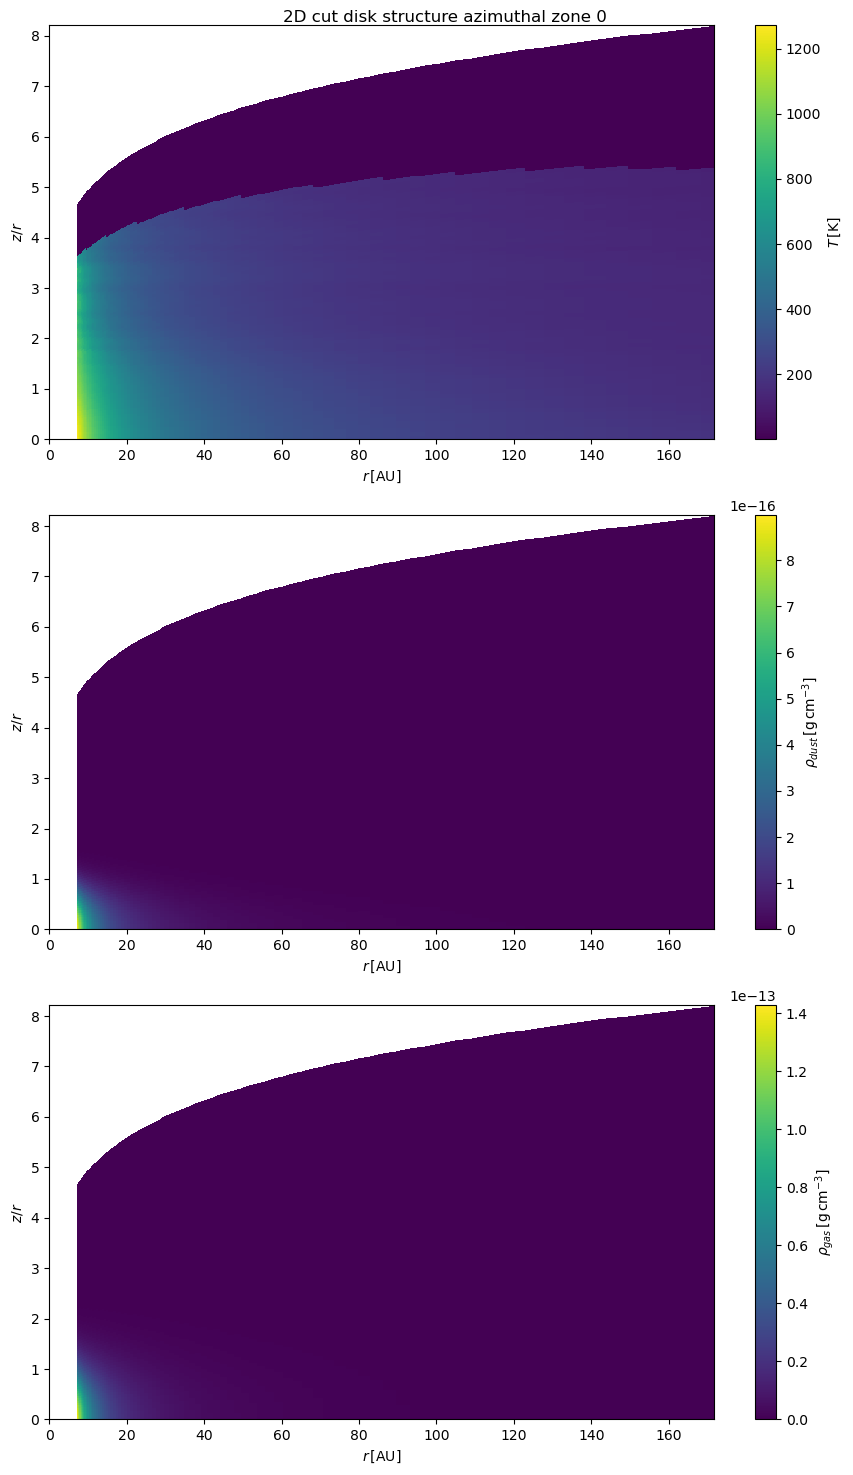

In [25]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_no_puffed_rim_budget1/smac_results/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


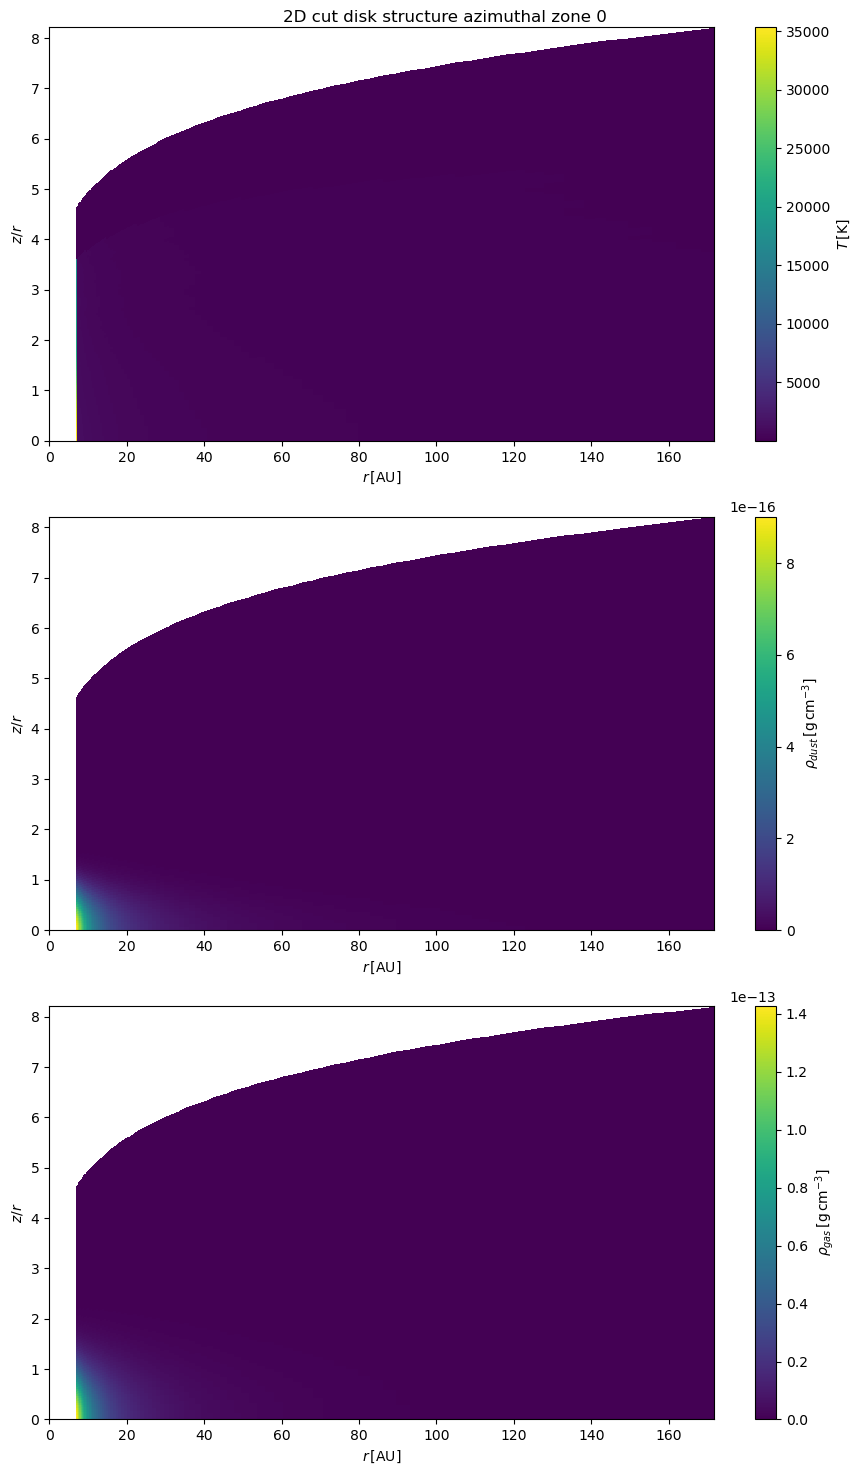

In [27]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260610_no_puffed_rim_migration_sublim/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


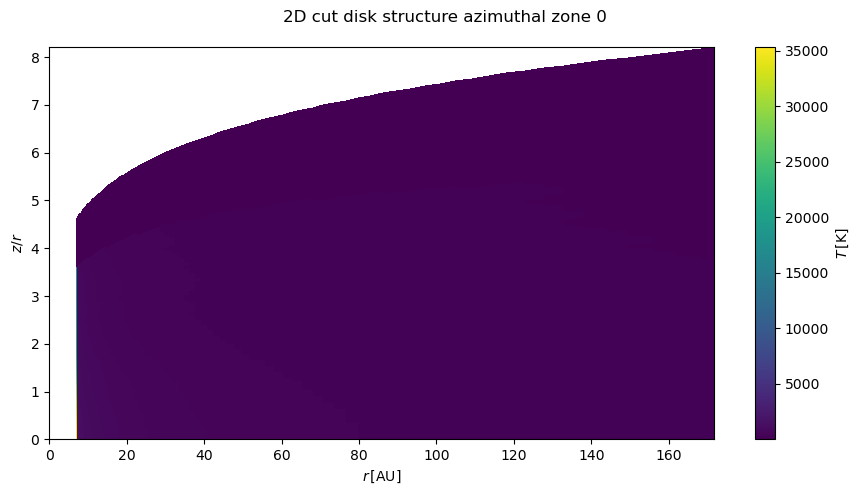

In [44]:
az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

#open the required temperature, dust and gas mass density fits files and plot them
paths=['data_th/Temperature.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    
    #plotting
    cmesh = ax.pcolormesh(r, z/r, quantity, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax)
    
    cb.set_label(r'$T \, \mathrm{[K]}$')
    ax.set_xlabel(r'$r \, \mathrm{[AU]}$')
    ax.set_ylabel(r'$z/r$')
    ax.set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    plt.show()

    

In [43]:
quantity_struct.max()


35345.6